Mounted at /content/drive
✓ Google Drive 已挂载
🚀 任务 7.1: 发现队列 ASD 患儿微生物组亚型聚类
正在加载发现队列与特征数据...
✅ 成功提取发现队列中 245 例 ASD 患儿进行聚类。
  - 轮廓系数评估完毕，最佳聚类数 (Subtypes) = 2 (Silhouette Score: 0.144)


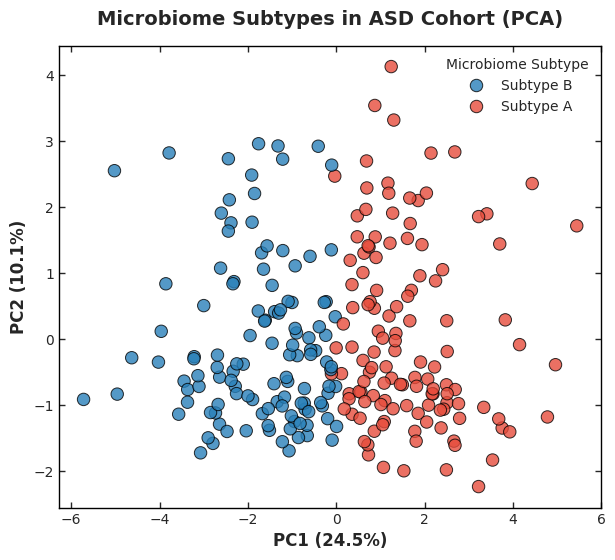

✓ 亚型聚类结果已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig5A_Subtypes_PCA.pdf


In [ ]:
# ============================================================
# Stage 7: Subtype Analysis and Clinical Association
# Cell 1: 7.1 Unsupervised clustering based on microbiome features (K-means)
# ============================================================
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from google.colab import drive

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
    print("✓ Google Drive 已挂载")

print("="*60)
print("🚀 任务 7.1: 发现队列 ASD 患儿微生物组亚型聚类")
print("="*60)

# 1. Path setup
BASE_PATH = '/content/drive/MyDrive/ASD_Research'
DATA_PATH = os.path.join(BASE_PATH, '02_merged_data')
FIG_PATH = os.path.join(BASE_PATH, '04_figures')
os.makedirs(FIG_PATH, exist_ok=True)

# 2. Robust matrix construction function
def build_matrix_robust(data_dict, feature_dict, group_series):
    X_list = []
    for dtype, feats in feature_dict.items():
        if not feats: continue
        if dtype not in data_dict or data_dict[dtype] is None: continue
        df_full = data_dict[dtype]
        if dtype == 'taxa':
            idx_keep = [i for i in df_full.index if 's__' in i and 't__' not in i]
            df_full = df_full.loc[idx_keep]
            df_full.index = [i.split('s__')[-1].replace('_', ' ') for i in df_full.index]
        existing = [f for f in feats if f in df_full.index]
        part_exist = df_full.loc[existing].T
        part_exist = part_exist[existing]
        part_exist.columns = [f"{dtype}|{c}" for c in part_exist.columns]
        X_list.append(part_exist)
    X_final = pd.concat(X_list, axis=1)
    common = X_final.index.intersection(group_series.index)
    return X_final.loc[common], group_series.loc[common]

# 3. Load data
print("正在加载发现队列与特征数据...")
with open(os.path.join(DATA_PATH, 'stage2_normalized_data.pkl'), 'rb') as f:
    stage2_data = pickle.load(f)
with open(os.path.join(DATA_PATH, 'stage5_ml_results.pkl'), 'rb') as f:
    stage5_results = pickle.load(f)

X_omics, y_omics = build_matrix_robust(
    stage2_data['discovery_data_corrected'],
    stage5_results['feature_list'],
    stage2_data['discovery_group']
)

# 4. Extract ASD cases for internal subtype analysis
asd_mask = y_omics == 'ASD'
X_asd_all = X_omics[asd_mask].copy()
print(f"✅ 成功提取发现队列中 {len(X_asd_all)} 例 ASD 患儿进行聚类。")

# 5. Standardize the data (K-means is sensitive to feature scale, so standardization is required)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_asd_all)

# 6. Determine the optimal number of clusters K (using the silhouette score)
best_k = 2
best_score = -1
scores = []
K_range = range(2, 6)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_temp)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_k = k

print(f"  - 轮廓系数评估完毕，最佳聚类数 (Subtypes) = {best_k} (Silhouette Score: {best_score:.3f})")

# 7. Run the final K-means clustering
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
X_asd_all['Subtype'] = kmeans.fit_predict(X_scaled)

# Map to more publication-ready labels
subtype_map = {i: f"Subtype {chr(65+i)}" for i in range(best_k)} # 转换为 Subtype A, Subtype B...
X_asd_all['Subtype_Label'] = X_asd_all['Subtype'].map(subtype_map)

# 8. Visualize dimensionality reduction with PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
X_asd_all['PC1'] = pcs[:, 0]
X_asd_all['PC2'] = pcs[:, 1]
var_exp = pca.explained_variance_ratio_

plt.figure(figsize=(7, 6))
sns.set_style("ticks")

# Define subtype colors (publication-style palette)
palette = {'Subtype A': '#E74C3C', 'Subtype B': '#2980B9', 'Subtype C': '#27AE60', 'Subtype D': '#8E44AD'}

sns.scatterplot(
    data=X_asd_all, x='PC1', y='PC2', hue='Subtype_Label',
    palette=palette, s=80, alpha=0.8, edgecolor='k'
)

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=12, fontweight='bold')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=12, fontweight='bold')
plt.title('Microbiome Subtypes in ASD Cohort (PCA)', fontsize=14, fontweight='bold', pad=15)
plt.legend(title='Microbiome Subtype', frameon=False, loc='best')

# Border settings
ax = plt.gca()
ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

out_fig7a = os.path.join(FIG_PATH, 'Fig5A_Subtypes_PCA.pdf')
plt.savefig(out_fig7a, bbox_inches='tight')

plt.show()

print(f"✓ 亚型聚类结果已保存至: {out_fig7a}")

# Save clustering results for use in Section 7.2
X_asd_all[['Subtype', 'Subtype_Label']].to_csv(os.path.join(DATA_PATH, 'stage7_subtypes.csv'))


🚀 任务 7.2: 比较不同亚型的临床行为评分差异
✅ 成功匹配到 35 例长春队列 ASD 患儿的临床数据与亚型标签。
Subtype_Label
Subtype A    19
Subtype B    16
Name: count, dtype: int64
  - 无显著差异: ABC Total Score -> P-value: 0.3624
  - 无显著差异: Sensory Ability -> P-value: 0.5171
  - 无显著差异: Social Ability -> P-value: 0.5053
  - 无显著差异: Motor Ability -> P-value: 0.0741
  - 无显著差异: Language Ability -> P-value: 0.8293
  - 无显著差异: Self Care Ability -> P-value: 0.4858


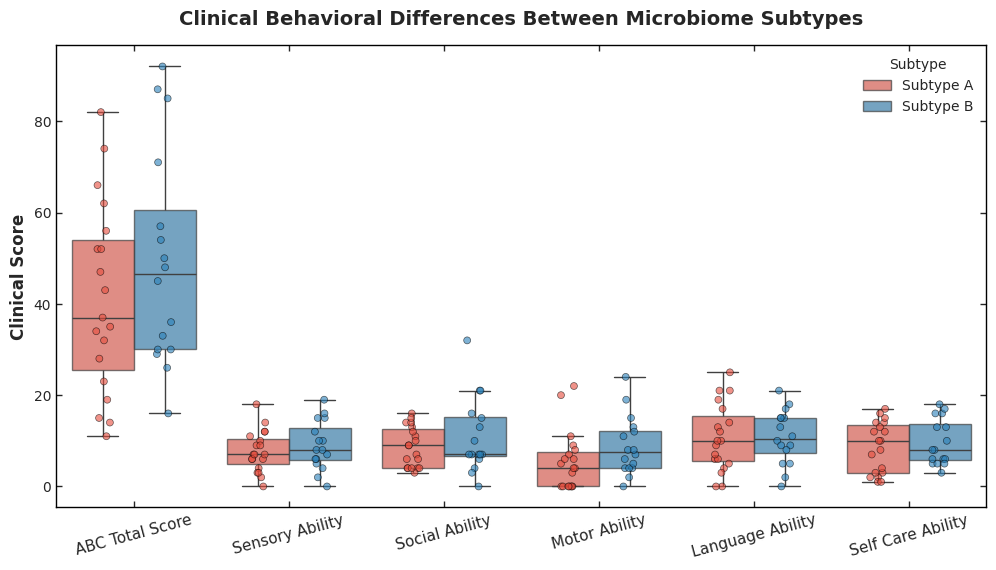


✓ 亚型临床比较图已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig5B_Subtype_Clinical_Comparison.pdf


In [ ]:
# ============================================================
# Cell 2: 7.2 Subtype-behavior association (Changchun cohort) - fixed index loss issue
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

print("\n" + "="*60)
print("🚀 任务 7.2: 比较不同亚型的临床行为评分差异")
print("="*60)

META_PATH = os.path.join(BASE_PATH, '03_metadata_tables')

# 1. Load clinical data
clin_csv_path = os.path.join(META_PATH, 'Table4_Clinical_Behavior_Scores.csv')
clin_df = pd.read_csv(clin_csv_path)
clin_df['Sample_ID'] = clin_df['Sample_ID'].astype(str).str.strip()
clin_df.set_index('Sample_ID', inplace=True)

# 2. Merge and match with clustering results (keep only Changchun samples with clinical data)
subtype_df = pd.read_csv(os.path.join(DATA_PATH, 'stage7_subtypes.csv'), index_col=0)
merged_df = clin_df.join(subtype_df, how='inner')

# Core fix: forcibly rename the index to Sample_ID to prevent missing-column errors after reset_index
merged_df.index.name = 'Sample_ID'

# Extract score columns and remove missing values
clin_cols = ['ABC_Total_Score', 'Sensory_Ability', 'Social_Ability',
             'Motor_Ability', 'Language_Ability', 'Self_Care_Ability']
merged_df = merged_df.dropna(subset=clin_cols + ['Subtype_Label'])

print(f"✅ 成功匹配到 {len(merged_df)} 例长春队列 ASD 患儿的临床数据与亚型标签。")
print(merged_df['Subtype_Label'].value_counts())

# 3. Reshape the data with melt so Seaborn can draw high-quality multi-panel box plots
melted_df = pd.melt(
    merged_df.reset_index(),
    id_vars=['Sample_ID', 'Subtype_Label'],
    value_vars=clin_cols,
    var_name='Clinical_Domain',
    value_name='Score'
)

# Clean tick labels
melted_df['Clinical_Domain'] = melted_df['Clinical_Domain'].str.replace('_', ' ')

# 4. Draw comparative box plots (boxplot + stripplot)
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

palette = {'Subtype A': '#E74C3C', 'Subtype B': '#2980B9', 'Subtype C': '#27AE60'}

ax = sns.boxplot(
    x='Clinical_Domain', y='Score', hue='Subtype_Label',
    data=melted_df, palette=palette, fliersize=0, boxprops={'alpha': 0.7}
)
# Overlay scatter points to show the true distribution
sns.stripplot(
    x='Clinical_Domain', y='Score', hue='Subtype_Label',
    data=melted_df, palette=palette, dodge=True, alpha=0.6, size=5, edgecolor='k', linewidth=0.5
)

# 5. Automatically run statistical tests and annotate P-values (assuming 2 subtypes here, using Mann-Whitney U)
subtypes = sorted(merged_df['Subtype_Label'].unique())
if len(subtypes) == 2:
    subtype_1, subtype_2 = subtypes[0], subtypes[1]

    # Iterate through each clinical domain
    for i, domain in enumerate(melted_df['Clinical_Domain'].unique()):
        # Note that the original underscore-containing names must be restored for DataFrame lookup
        data_1 = merged_df[merged_df['Subtype_Label'] == subtype_1][domain.replace(' ', '_')]
        data_2 = merged_df[merged_df['Subtype_Label'] == subtype_2][domain.replace(' ', '_')]

        # Nonparametric test
        stat, p = mannwhitneyu(data_1, data_2, alternative='two-sided')

        # Add stars to the figure if significant
        if p < 0.05:
            y_max = melted_df[melted_df['Clinical_Domain'] == domain]['Score'].max()
            plt.text(i, y_max + 2, f'P = {p:.3f}\n*', ha='center', va='bottom', fontsize=11, fontweight='bold', color='red')
            print(f"  ⭐ 显著差异发现: {domain} ({subtype_1} vs {subtype_2}) -> P-value: {p:.4f}")
        else:
            print(f"  - 无显著差异: {domain} -> P-value: {p:.4f}")

plt.xlabel('')
plt.ylabel('Clinical Score', fontsize=12, fontweight='bold')
plt.title('Clinical Behavioral Differences Between Microbiome Subtypes', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=15, fontsize=11)

# Remove redundant legends
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:len(subtypes)], labels[:len(subtypes)], title='Subtype', frameon=False, loc='upper right')

# Border settings (Nature style)
ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

out_fig7b = os.path.join(FIG_PATH, 'Fig5B_Subtype_Clinical_Comparison.pdf')
plt.savefig(out_fig7b, bbox_inches='tight')
plt.show()

print(f"\n✓ 亚型临床比较图已保存至: {out_fig7b}")


🚀 任务 7.3: 比较不同亚型的饮食与胃肠道特征

📊 Diet_Type 交叉分布表:
Diet_Binary    Normal  Picky/Avoidant
Subtype_Label                        
Subtype A          10               9
Subtype B          11               5
  👉 卡方检验 P-value: 0.5331

📊 GI_Symptoms 交叉分布表:
GI_Symptoms    No  Yes
Subtype_Label         
Subtype A      19    0
Subtype B      15    1
  👉 卡方检验 P-value: 0.9304


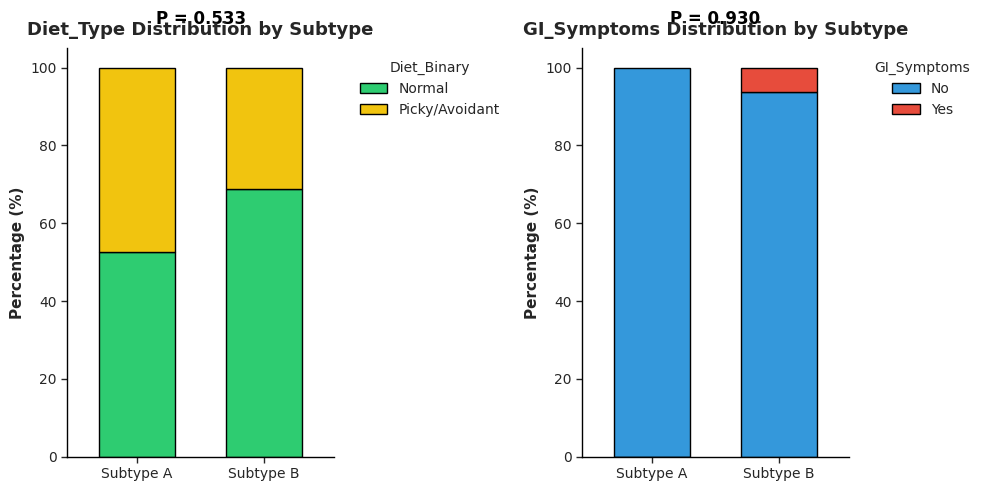


✓ 饮食与胃肠道特征关联图已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig5C_Subtype_Diet_GI_Distribution.pdf


In [ ]:
# ============================================================
# Cell 3: 7.3 Association analysis of subtypes with diet/gastrointestinal symptoms (chi-square test)
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("\n" + "="*60)
print("🚀 任务 7.3: 比较不同亚型的饮食与胃肠道特征")
print("="*60)

# 1. Dependency check (requires merged_df from Cell 2)
if 'merged_df' not in globals():
    raise NameError("❌ 错误: 未找到临床与亚型合并数据。请先运行 Cell 2！")

# 2. Prepare categorical feature data
cat_cols = ['Diet_Type', 'GI_Symptoms']
for col in cat_cols:
    if col not in merged_df.columns:
        print(f"⚠ 警告: 临床数据中未找到列 {col}，跳过该指标分析。")
        continue

# Create the figure canvas (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.set_style("white")

# Define an attractive categorical color palette
colors_diet = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C', '#9B59B6', '#34495E']
colors_gi = ['#3498DB', '#E74C3C', '#95A5A6']

for idx, col in enumerate(cat_cols):
    # 2.1 Clean the data: remove missing values or "Unknown" entries
    clean_df = merged_df[merged_df[col].notna() & (merged_df[col] != 'Unknown')].copy()

    if len(clean_df) == 0:
        print(f"  - {col}: 没有足够的有效数据进行分析。")
        continue

    # 2.2 Simplify diet categories (optional, because too many categories in a small sample can invalidate the statistics)
    # Collapse all non-Normal diet categories into "Abnormal/Picky"
    if col == 'Diet_Type':
        clean_df['Diet_Binary'] = clean_df['Diet_Type'].apply(lambda x: 'Normal' if x == 'Normal' else 'Picky/Avoidant')
        target_col = 'Diet_Binary'
    else:
        target_col = col

    # 2.3 Build the contingency table
    crosstab = pd.crosstab(clean_df['Subtype_Label'], clean_df[target_col])

    print(f"\n📊 {col} 交叉分布表:")
    print(crosstab)

    # 2.4 Statistical test (chi-square test)
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"  👉 卡方检验 P-value: {p:.4f}")
    if p < 0.05:
        print(f"  ⭐ 发现显著差异！亚型之间的 {col} 存在统计学上的明显不同。")

    # 2.5 Draw a 100% stacked bar chart
    # Convert to row-wise percentages
    crosstab_pct = crosstab.div(crosstab.sum(1), axis=0) * 100

    ax = axes[idx]
    crosstab_pct.plot(kind='bar', stacked=True, ax=ax,
                      color=colors_diet if idx==0 else colors_gi, edgecolor='black', width=0.6)

    # Style the figure
    ax.set_title(f'{col} Distribution by Subtype', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    # Annotate P-values on the bars
    p_text = f'P = {p:.3f}' + ('*' if p < 0.05 else '')
    ax.text(0.5, 1.05, p_text, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='red' if p < 0.05 else 'black')

    # Border settings
    ax.tick_params(direction='out', length=4, width=1, right=False, top=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.0)
        ax.spines[spine].set_edgecolor('black')

plt.tight_layout()

out_fig7c = os.path.join(FIG_PATH, 'Fig5C_Subtype_Diet_GI_Distribution.pdf')
plt.savefig(out_fig7c, bbox_inches='tight')
plt.show()

print(f"\n✓ 饮食与胃肠道特征关联图已保存至: {out_fig7c}")


🚀 任务 7.4: 揭示驱动亚型分化的核心组学特征
正在计算特征差异并逐一绘制独立箱线图...



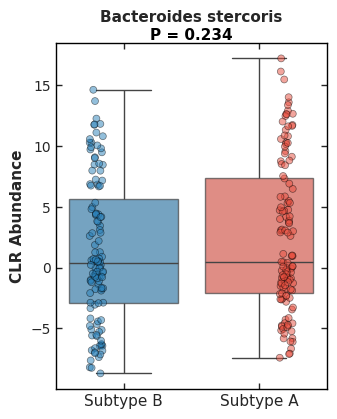

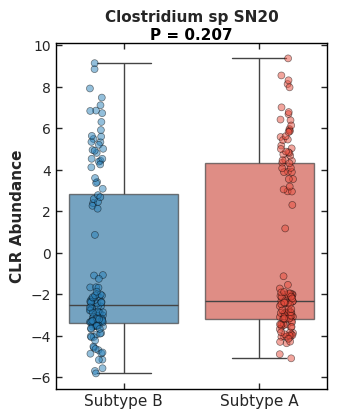

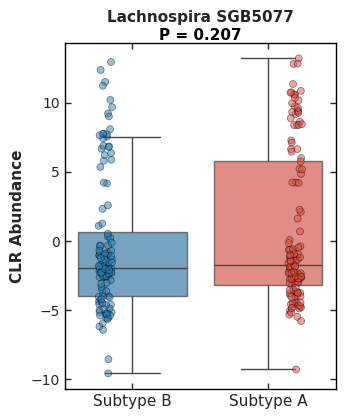

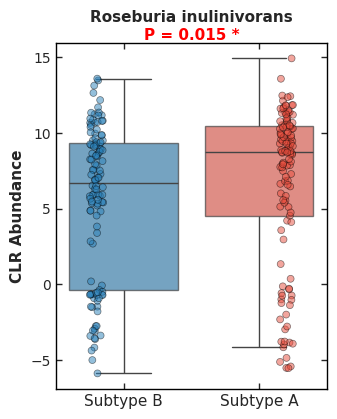

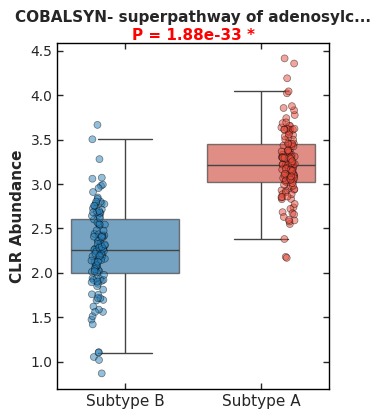

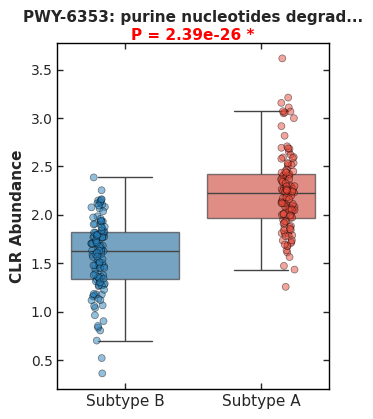

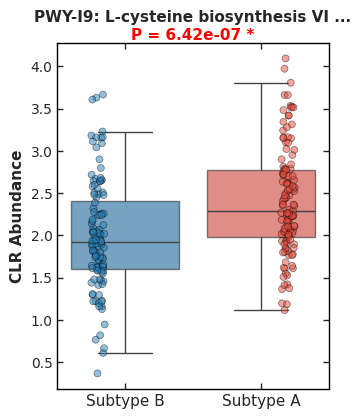

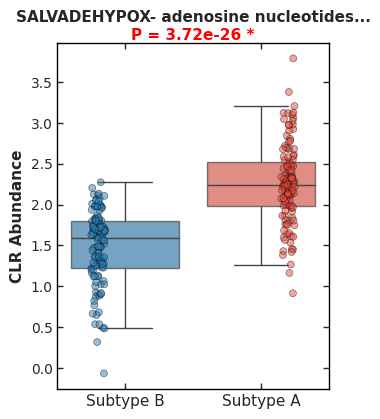

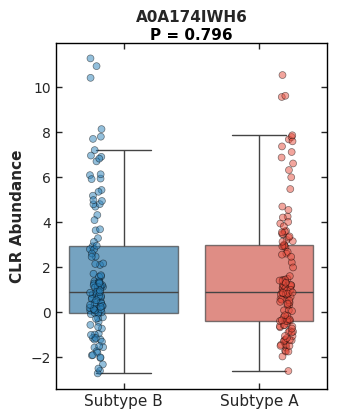

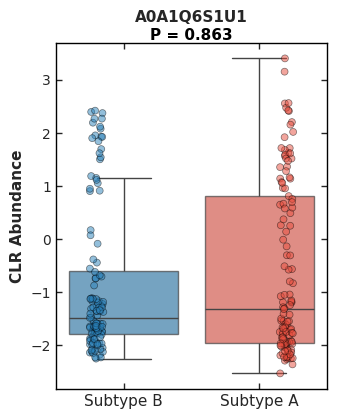

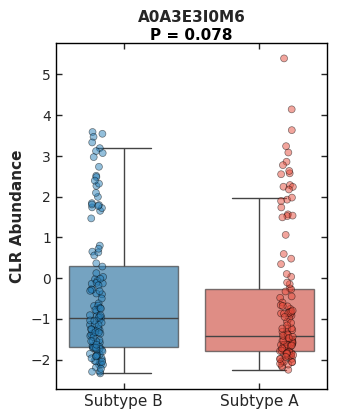

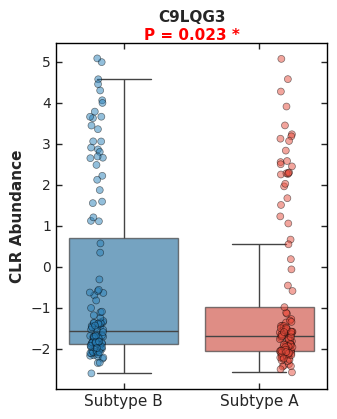

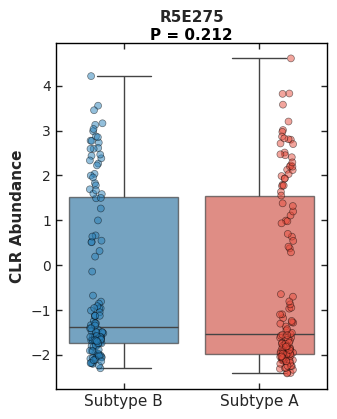

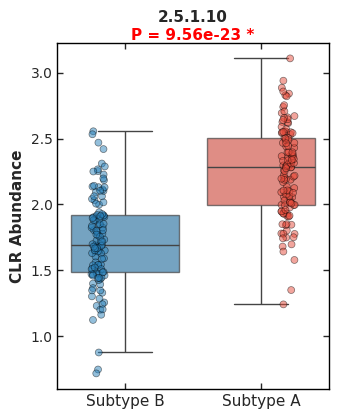

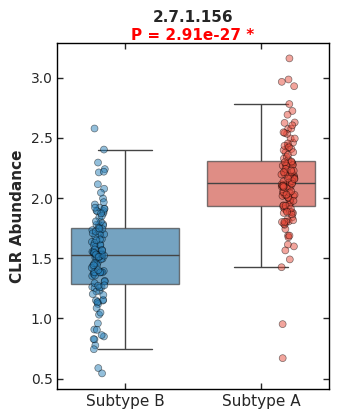

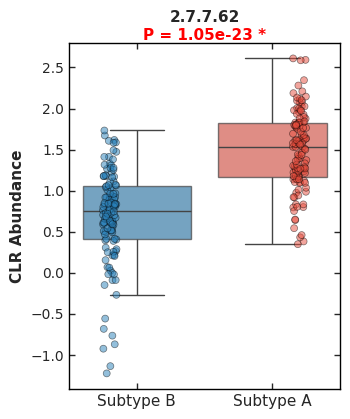

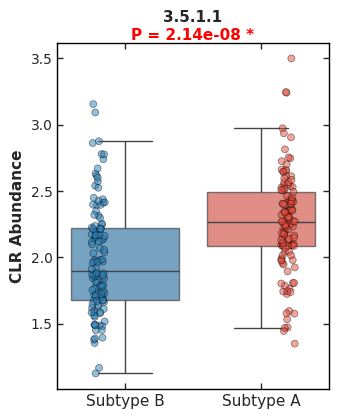

✓ 成功生成 17 张独立的特征差异箱线图，已保存至 04_figures 目录！

正在绘制亚型分子全景热图...


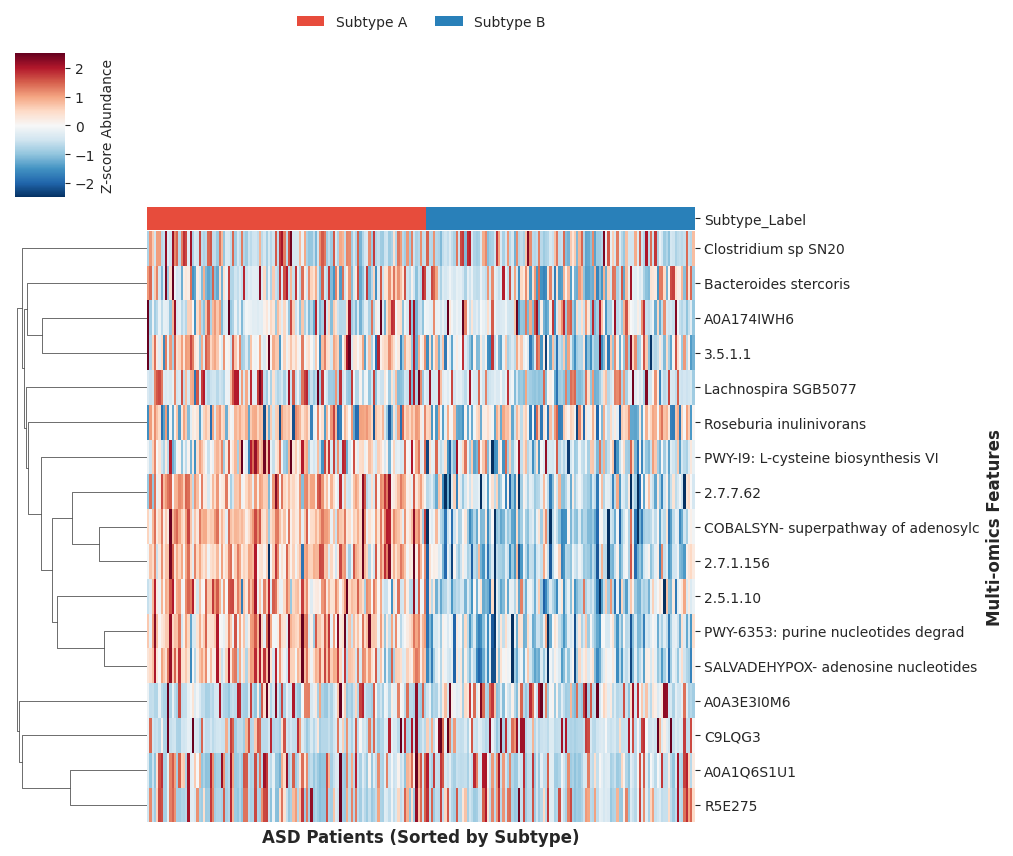

✓ 亚型分子全景热图已保存至: /content/drive/MyDrive/ASD_Research/04_figures/Fig5E_Subtype_Landscape_Heatmap.pdf

🎉 Stage 7 全部任务完美通关！


In [ ]:
# ============================================================
# Cell 4 (final plotting version): 7.4 Subtype-driving feature analysis (independent box plots and heatmap)
# ============================================================
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler

print("\n" + "="*60)
print("🚀 任务 7.4: 揭示驱动亚型分化的核心组学特征")
print("="*60)

# 1. Dependency check (requires X_asd_all from Cell 1)
if 'X_asd_all' not in globals():
    raise NameError("❌ 错误: 未找到亚型数据。请先运行 Stage 7 的 Cell 1！")

# Extract feature columns and subtype labels
features = [c for c in X_asd_all.columns if c not in ['Subtype', 'Subtype_Label', 'PC1', 'PC2']]
df_plot = X_asd_all.copy()

# Extract the names of the two major subtypes
subtypes = sorted(df_plot['Subtype_Label'].dropna().unique())
if len(subtypes) < 2:
    raise ValueError("亚型数量不足2个，无法进行比较！")
sub1, sub2 = subtypes[0], subtypes[1]
palette = {sub1: '#E74C3C', sub2: '#2980B9'}

# ---------------------------------------------------------
# Figure A: Differential box plots of 17 core features between the two subtypes (drawn individually)
# ---------------------------------------------------------
print("正在计算特征差异并逐一绘制独立箱线图...\n")

count = 0
for feat in features:
    # Compute statistical differences
    data1 = df_plot[df_plot['Subtype_Label'] == sub1][feat]
    data2 = df_plot[df_plot['Subtype_Label'] == sub2][feat]
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')

    count += 1

    # Extract and clean feature names (for display and file saving)
    raw_name = feat.split('|')[-1].replace('UniRef90_', '').replace('PWY:', '')
    display_name = raw_name[:35] + '...' if len(raw_name) > 35 else raw_name
    safe_filename = re.sub(r'[^a-zA-Z0-9]', '_', raw_name[:20])

    # Create a standalone canvas
    plt.figure(figsize=(3.5, 4.5))
    sns.set_style("ticks")

    # Draw box plots and scatter points (fixing the Seaborn palette warning by adding hue and legend=False)
    ax = sns.boxplot(x='Subtype_Label', y=feat, hue='Subtype_Label', data=df_plot,
                     palette=palette, legend=False, fliersize=0, boxprops={'alpha': 0.7})
    sns.stripplot(x='Subtype_Label', y=feat, hue='Subtype_Label', data=df_plot,
                  palette=palette, legend=False, dodge=True, alpha=0.5, size=5, edgecolor='k', linewidth=0.5)

    # Smart P-value annotation (significant features are marked in red with stars)
    y_max = df_plot[feat].max()
    y_range = y_max - df_plot[feat].min()

    p_text = f'P = {p:.2e}' if p < 0.001 else f'P = {p:.3f}'
    if p < 0.05: p_text += ' *'
    text_color = 'red' if p < 0.05 else 'black'

    plt.text(0.5, y_max + y_range * 0.05, p_text, ha='center', va='bottom',
             color=text_color, fontsize=11, fontweight='bold')

    # Style the figure
    plt.title(display_name, fontsize=11, fontweight='bold', pad=15)
    plt.ylabel('CLR Abundance', fontsize=11, fontweight='bold')
    plt.xlabel('')
    plt.xticks(fontsize=11)

    # Border settings (Nature style)
    ax.tick_params(direction='in', length=4, width=1, top=True, right=True)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_edgecolor('black')

    # Save each individual figure
    out_fig_box = os.path.join(FIG_PATH, f'Fig5D_{count}_{safe_filename}.pdf')
    plt.savefig(out_fig_box, bbox_inches='tight')
    plt.show() # 在 Notebook 中逐一展示

print(f"✓ 成功生成 {count} 张独立的特征差异箱线图，已保存至 04_figures 目录！")

# ---------------------------------------------------------
# Figure B: Molecular landscape heatmap of subtypes
# ---------------------------------------------------------
print("\n正在绘制亚型分子全景热图...")

# Sort the data by subtype
df_sorted = df_plot.sort_values(by='Subtype_Label')

# Extract the feature matrix and apply Z-score standardization
X_heat = df_sorted[features]
scaler = StandardScaler()
X_heat_z = pd.DataFrame(scaler.fit_transform(X_heat), index=X_heat.index, columns=X_heat.columns)

# Clean column labels for display
clean_cols = [c.split('|')[-1].replace('UniRef90_', '').replace('PWY:', '')[:35] for c in X_heat_z.columns]
X_heat_z.columns = clean_cols

# Top color bar
subtype_colors = df_sorted['Subtype_Label'].map(palette)

# Draw the heatmap
g = sns.clustermap(
    X_heat_z.T,
    cmap='RdBu_r',
    col_cluster=False,  # 样本不聚类，严格按亚型排列
    row_cluster=True,   # 特征自动聚类
    col_colors=subtype_colors,
    vmin=-2.5, vmax=2.5,
    figsize=(10, 8),
    xticklabels=False,
    yticklabels=True,
    cbar_kws={'label': 'Z-score Abundance'}
)

g.ax_heatmap.set_xlabel('ASD Patients (Sorted by Subtype)', fontsize=12, fontweight='bold')
g.ax_heatmap.set_ylabel('Multi-omics Features', fontsize=12, fontweight='bold')

# Manually add the heatmap legend
for label, color in palette.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc="center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.2))

out_fig7e = os.path.join(FIG_PATH, 'Fig5E_Subtype_Landscape_Heatmap.pdf')
plt.savefig(out_fig7e, bbox_inches='tight')
plt.show()

print(f"✓ 亚型分子全景热图已保存至: {out_fig7e}")
print("\n🎉 Stage 7 全部任务完美通关！")

In [ ]:
!pip install scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 81.6 MB/s eta 0:00:00



🚀 任务 7.5: 比较不同亚型的整体微生物生态学多样性
正在计算 Alpha 多样性 (Shannon Index)...


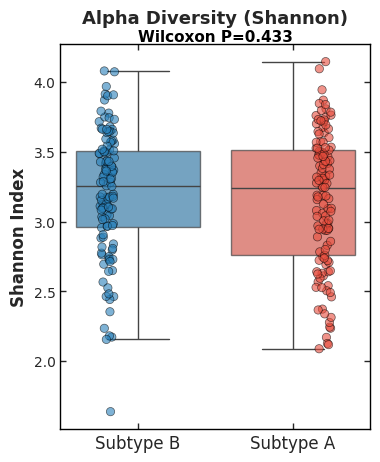


正在计算 Beta 多样性 (PCoA based on CLR/Aitchison distance) 及 PERMANOVA...
  ✅ PERMANOVA 检验完成: Pseudo-F = 1.71, P-value = 0.0030


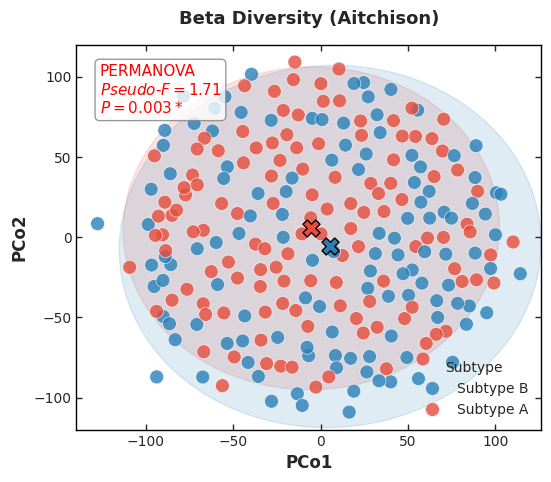

In [ ]:
# ============================================================
# Cell 5 (final version): 7.5 Ecological feature analysis of subtypes (alpha and beta diversity)
# ============================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.patches import Ellipse

# Try importing skbio
try:
    from skbio.diversity import alpha_diversity
    from skbio.stats.distance import DistanceMatrix, permanova
except ImportError:
    raise ImportError("❌ 错误: 未找到 scikit-bio。请确保环境与 Stage 3 相同。")

print("\n" + "="*60)
print("🚀 任务 7.5: 比较不同亚型的整体微生物生态学多样性")
print("="*60)

# 1. Dependency check and data preparation
if 'X_asd_all' not in globals() or 'stage2_data' not in globals():
    raise NameError("❌ 错误: 未找到亚型或Stage2基础数据。请确保前面单元格已运行！")

subtype_series = X_asd_all['Subtype_Label'].dropna()
palette = {'Subtype A': '#E74C3C', 'Subtype B': '#2980B9'}

# ---------------------------------------------------------
# Figure A: Alpha diversity (Shannon index)
# ---------------------------------------------------------
print("正在计算 Alpha 多样性 (Shannon Index)...")
df_raw = stage2_data['discovery_data_raw']['taxa'].copy()
idx_keep = [i for i in df_raw.index if 's__' in i and 't__' not in i]
df_raw = df_raw.loc[idx_keep]
df_raw.index = [i.split('s__')[-1].replace('_', ' ') for i in df_raw.index]

taxa_raw = df_raw.T
common_samples = taxa_raw.index.intersection(subtype_series.index)
taxa_raw_asd = taxa_raw.loc[common_samples]

counts = (taxa_raw_asd * 1e6).astype(int)
ids = counts.index

alpha_df = pd.DataFrame(index=ids)
try:
    alpha_df['Shannon_Index'] = alpha_diversity('shannon', counts.values, ids=ids)
except Exception as e:
    print(f"  计算 Shannon 出错: {e}")

alpha_df['Subtype_Label'] = subtype_series.loc[common_samples]

subtypes = sorted(alpha_df['Subtype_Label'].unique())
stat, p_alpha = stats.ranksums(
    alpha_df[alpha_df['Subtype_Label'] == subtypes[0]]['Shannon_Index'],
    alpha_df[alpha_df['Subtype_Label'] == subtypes[1]]['Shannon_Index']
)

plt.figure(figsize=(4, 5))
sns.set_style("ticks")
ax_alpha = sns.boxplot(x='Subtype_Label', y='Shannon_Index', hue='Subtype_Label', data=alpha_df,
                       palette=palette, legend=False, fliersize=0, boxprops={'alpha': 0.7})
sns.stripplot(x='Subtype_Label', y='Shannon_Index', hue='Subtype_Label', data=alpha_df,
              palette=palette, legend=False, dodge=True, alpha=0.6, size=6, edgecolor='k', linewidth=0.5)

y_max = alpha_df['Shannon_Index'].max()
y_range = y_max - alpha_df['Shannon_Index'].min()
p_text = f'Wilcoxon P={p_alpha:.2e}' if p_alpha < 0.001 else f'Wilcoxon P={p_alpha:.3f}'
if p_alpha < 0.05: p_text += ' *'
plt.text(0.5, y_max + y_range * 0.05, p_text, ha='center', va='bottom',
         color='red' if p_alpha < 0.05 else 'black', fontsize=11, fontweight='bold')

plt.title('Alpha Diversity (Shannon)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Shannon Index', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.xticks(fontsize=12)

ax_alpha.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax_alpha.spines.values():
    spine.set_linewidth(1.0)
    spine.set_edgecolor('black')

out_fig7f = os.path.join(FIG_PATH, 'Fig5F_Subtype_Alpha_Diversity.pdf')
plt.savefig(out_fig7f, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Figure B: Beta diversity (PCoA + PERMANOVA)
# ---------------------------------------------------------
print("\n正在计算 Beta 多样性 (PCoA based on CLR/Aitchison distance) 及 PERMANOVA...")
df_clr = stage2_data['discovery_data_corrected']['taxa'].copy()
df_clr = df_clr.loc[idx_keep]
df_clr.index = [i.split('s__')[-1].replace('_', ' ') for i in df_clr.index]

X_df = df_clr.T.loc[common_samples]

if X_df.isnull().values.any() or np.isinf(X_df.values).any():
    X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

dist_matrix = euclidean_distances(X_df, X_df)
dist_matrix = (dist_matrix + dist_matrix.T) / 2
np.fill_diagonal(dist_matrix, 0)
if np.isnan(dist_matrix).any():
    dist_matrix = np.nan_to_num(dist_matrix, nan=0.0)

# --- New: run the PERMANOVA test ---
try:
    dm = DistanceMatrix(dist_matrix, ids=common_samples)
    perm_res = permanova(dm, grouping=subtype_series.loc[common_samples].values, permutations=999)
    p_beta = perm_res['p-value']
    f_stat = perm_res['test statistic']
    print(f"  ✅ PERMANOVA 检验完成: Pseudo-F = {f_stat:.2f}, P-value = {p_beta:.4f}")
except Exception as e:
    print(f"  ❌ PERMANOVA 检验失败: {e}")
    p_beta, f_stat = 1.0, 0.0

# Perform dimensionality reduction with PCoA
pcoa = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = pcoa.fit_transform(dist_matrix)

beta_df = pd.DataFrame({'PCo1': coords[:, 0], 'PCo2': coords[:, 1], 'Subtype_Label': subtype_series.loc[common_samples]})

fig, ax_beta = plt.subplots(figsize=(6, 5))
sns.set_style("ticks")

sns.scatterplot(x='PCo1', y='PCo2', hue='Subtype_Label', data=beta_df,
                palette=palette, s=100, alpha=0.8, edgecolor='white', linewidth=0.5, ax=ax_beta)

for sub in subtypes:
    sub_data = beta_df[beta_df['Subtype_Label'] == sub]
    x, y = sub_data['PCo1'].values, sub_data['PCo2'].values
    c = palette[sub]
    centroid_x, centroid_y = np.mean(x), np.mean(y)
    ax_beta.scatter(centroid_x, centroid_y, c=c, s=150, marker='X', edgecolors='black', linewidth=1, zorder=3)

    if len(x) > 5:
        try:
            cov = np.cov(x, y)
            lambda_, v = np.linalg.eig(cov)
            ell = Ellipse(xy=(centroid_x, centroid_y), width=np.sqrt(lambda_[0])*4, height=np.sqrt(lambda_[1])*4,
                          angle=np.rad2deg(np.arccos(v[0, 0])), color=c, alpha=0.15, zorder=0)
            ax_beta.add_artist(ell)
        except: pass

# --- New: elegantly annotate PERMANOVA results on the plot ---
p_beta_text = f'P = {p_beta:.3f}' if p_beta >= 0.001 else 'P < 0.001'
if p_beta < 0.05: p_beta_text += ' *'
textstr = '\n'.join((r'PERMANOVA', r'$Pseudo\text{-}F=%.2f$' % (f_stat, ), r'$%s$' % (p_beta_text, )))
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
ax_beta.text(0.05, 0.95, textstr, transform=ax_beta.transAxes, fontsize=11,
             verticalalignment='top', bbox=props, color='red' if p_beta < 0.05 else 'black')

ax_beta.set_xlabel('PCo1', fontsize=12, fontweight='bold')
ax_beta.set_ylabel('PCo2', fontsize=12, fontweight='bold')
plt.title('Beta Diversity (Aitchison)', fontsize=13, fontweight='bold', pad=15)
plt.legend(title='Subtype', frameon=False, loc='lower right')

ax_beta.tick_params(direction='in', length=4, width=1, top=True, right=True)
for spine in ax_beta.spines.values():
    spine.set_linewidth(1.0); spine.set_edgecolor('black')

out_fig7g = os.path.join(FIG_PATH, 'Fig5G_Subtype_Beta_Diversity.pdf')
plt.savefig(out_fig7g, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cell 6: Final manuscript step - automatically generate baseline characteristic tables in SCI format
# ============================================================
import os
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency

print("\n" + "="*60)
print("📝 任务: 自动生成学术论文基线统计表 (Table 1 & Table S1)")
print("="*60)

# Define paths
META_PATH = os.path.join(BASE_PATH, '03_metadata_tables')
df_global = pd.read_csv(os.path.join(META_PATH, 'Table3_Analytical_Metadata.csv'))
df_local = pd.read_csv(os.path.join(META_PATH, 'Table4_Clinical_Behavior_Scores.csv'))

# ---------------------------------------------------------
# 1. Create Table 1: Precise baseline table for the local Changchun cohort (with statistical tests)
# ---------------------------------------------------------
print("正在计算长春本地队列 (n=70) 的临床统计检验...")

asd_local = df_local[df_local['Group'] == 'ASD']
td_local = df_local[df_local['Group'] == 'TD']

table1 = []

# (1) Sample size N
table1.append(['Sample Size (N)', f"N = {len(asd_local)}", f"N = {len(td_local)}", ""])

# (2) Age - Mean ± SD and t-test
age_asd, age_td = asd_local['Age'], td_local['Age']
t_stat, p_age = stats.ttest_ind(age_asd, age_td)
table1.append([
    'Age (years, Mean ± SD)',
    f"{age_asd.mean():.2f} ± {age_asd.std():.2f}",
    f"{age_td.mean():.2f} ± {age_td.std():.2f}",
    f"{p_age:.3f}"
])

# (3) Sex - male/female counts and chi-square test
sex_xtab = pd.crosstab(df_local['Group'], df_local['Sex'])
chi2, p_sex, _, _ = chi2_contingency(sex_xtab)
male_asd, female_asd = (sex_xtab.loc['ASD', 'Male'], sex_xtab.loc['ASD', 'Female']) if 'Male' in sex_xtab.columns else (0,0)
male_td, female_td = (sex_xtab.loc['TD', 'Male'], sex_xtab.loc['TD', 'Female']) if 'Male' in sex_xtab.columns else (0,0)

table1.append(['Sex (Male/Female)', f"{male_asd}/{female_asd}", f"{male_td}/{female_td}", f"{p_sex:.3f}"])

# (4) Total ABC clinical score (mainly meaningful within the ASD group or for comparison)
t_stat, p_abc = stats.ttest_ind(asd_local['ABC_Total_Score'], td_local['ABC_Total_Score'])
table1.append([
    'ABC Total Score',
    f"{asd_local['ABC_Total_Score'].mean():.1f} ± {asd_local['ABC_Total_Score'].std():.1f}",
    f"{td_local['ABC_Total_Score'].mean():.1f} ± {td_local['ABC_Total_Score'].std():.1f}",
    f"{p_abc:.3f}" if p_abc >= 0.001 else "<0.001*"
])

# (5) Gastrointestinal symptoms and picky-eating proportion (descriptive statistics within the ASD group only)
gi_asd = (asd_local['GI_Symptoms'] == 'Yes').sum()
picky_asd = asd_local['Diet_Type'].apply(lambda x: 1 if x != 'Normal' else 0).sum()
table1.append(['GI Symptoms (Yes, n %)', f"{gi_asd} ({gi_asd/len(asd_local)*100:.1f}%)", "Not Evaluated", "-"])
table1.append(['Picky Eater (Yes, n %)', f"{picky_asd} ({picky_asd/len(asd_local)*100:.1f}%)", "Not Evaluated", "-"])

# Generate the DataFrame and save it
df_table1 = pd.DataFrame(table1, columns=['Characteristics', 'ASD Group', 'TD Group', 'P-value'])
out_t1 = os.path.join(META_PATH, 'Table1_Local_Cohort_Baseline.csv')
df_table1.to_csv(out_t1, index=False)
print(f"✓ Table 1 成功生成并保存至: {out_t1}")

# ---------------------------------------------------------
# 2. Create Table S1: Overall statistics for the global multicenter cohorts
# ---------------------------------------------------------
print("正在汇总全球多中心发现与验证队列大盘...")

# Extract batch and region distributions
summary = df_global.groupby(['Study_ID', 'Region', 'Batch']).agg(
    Total_N=('Sample_ID', 'count'),
    ASD_N=('Condition', lambda x: (x == 'ASD').sum()),
    TD_N=('Condition', lambda x: (x == 'TD').sum()),
    Age_Range=('Age_Category', lambda x: x.mode()[0] if not x.empty else 'Unknown')
).reset_index()

# Rename columns to match academic conventions
summary.rename(columns={
    'Study_ID': 'Cohort / Study',
    'Region': 'Geographic Region',
    'Batch': 'Accession / Batch ID',
    'Total_N': 'Total Samples',
    'ASD_N': 'ASD (n)',
    'TD_N': 'TD (n)',
    'Age_Range': 'Dominant Age Range'
}, inplace=True)

out_ts1 = os.path.join(META_PATH, 'TableS1_Global_Cohorts_Summary.csv')
summary.to_csv(out_ts1, index=False)
print(f"✓ Table S1 (补充材料表) 成功生成并保存至: {out_ts1}")

print("\n🎉 全部图表与基线数据表均已集齐！您现在可以直接用它们撰写 Manuscript（手稿）了！")


📝 任务: 自动生成学术论文基线统计表 (Table 1 & Table S1)
正在计算长春本地队列 (n=70) 的临床统计检验...
✓ Table 1 成功生成并保存至: /content/drive/MyDrive/ASD_Research/03_metadata_tables/Table1_Local_Cohort_Baseline.csv
正在汇总全球多中心发现与验证队列大盘...
✓ Table S1 (补充材料表) 成功生成并保存至: /content/drive/MyDrive/ASD_Research/03_metadata_tables/TableS1_Global_Cohorts_Summary.csv

🎉 全部图表与基线数据表均已集齐！您现在可以直接用它们撰写 Manuscript（手稿）了！
